# 物流延误与客户评价/体验


基于 Olist 的物流延误对评价/体验的影响分析。

**口径说明**：延误率、差评率等订单级指标使用 `v_order_delay`（按 `order_id` 去重一单一行），避免宽表 JOIN 膨胀。


## 1. 环境准备


In [2]:
import duckdb
import os
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
_db_candidates = [
    os.path.join(_root, 'smartquery.duckdb'),
    os.path.join(os.getcwd(), 'smartquery.duckdb'),
    r'E:/workspace/smartquery.duckdb',
]
_db = next((p for p in _db_candidates if os.path.exists(p)), None)
if _db is None:
    raise FileNotFoundError('找不到 smartquery.duckdb，请先运行 scripts/data_cleaning.py')
con = duckdb.connect(_db)
print('db:', _db)
print('明细行 v_analysis_base:', con.execute('SELECT COUNT(*) FROM v_analysis_base').fetchone()[0])
print('订单级 v_order_delay:', con.execute('SELECT COUNT(*) FROM v_order_delay').fetchone()[0])

rows: 117741


## 2. 延误概览


In [3]:
# 订单级：按 order_id 去重后的 v_order_delay
df = con.execute('''
SELECT
    ROUND(100.0 * SUM(is_delayed) / COUNT(*), 2) AS rate,
    ROUND(AVG(CASE WHEN is_delayed = 1 THEN delay_days END), 1) AS avg_delay,
    COUNT(*) AS total_orders
FROM v_order_delay
''').fetchdf()


In [4]:
print(df.to_string(index=False))


 rate  avg_delay
 6.53       10.6


## 3. 延误 vs 准点评分


In [5]:
r = con.execute('''
SELECT
    is_delayed,
    COUNT(*) AS cnt,
    ROUND(AVG(review_score), 2) AS avg_score,
    ROUND(100.0 * SUM(CASE WHEN review_score <= 2 THEN 1 ELSE 0 END) / COUNT(*), 2) AS bad_review_rate
FROM v_order_delay
WHERE review_score IS NOT NULL
GROUP BY is_delayed
''').fetchdf()


In [6]:
print(r.to_string(index=False))


 is_delayed    cnt  avg_score
          0 107487       4.21
          1   7367       2.25


## 4. 容忍度曲线


  grp    cnt    br
  ' ' 107487 11.51
'1-3'   2145 33.85
'4-7'   2028 68.39
 '8+'   3194 79.24


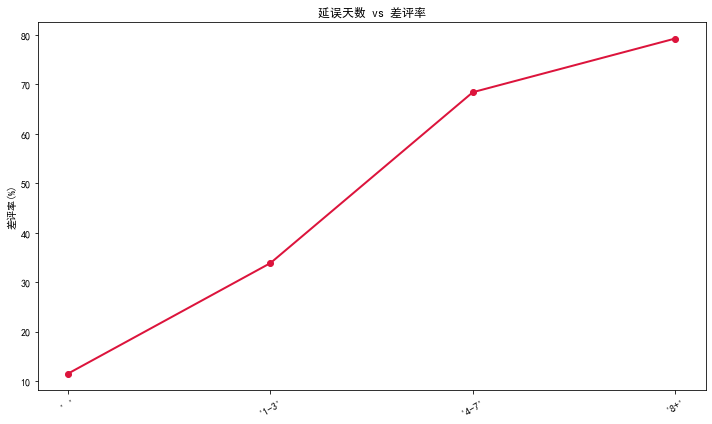

In [11]:
r = con.execute('''
SELECT
    CASE
        WHEN delay_days <= 0 THEN '准时/提前'
        WHEN delay_days <= 3 THEN '1-3天'
        WHEN delay_days <= 7 THEN '4-7天'
        ELSE '8天+'
    END AS grp,
    COUNT(*) AS cnt,
    ROUND(100.0 * SUM(CASE WHEN review_score <= 2 THEN 1 ELSE 0 END) / COUNT(*), 2) AS br
FROM v_order_delay
WHERE review_score IS NOT NULL
GROUP BY grp
ORDER BY MIN(delay_days)
''').fetchdf()
print(r.to_string(index=False))
os.makedirs('../outputs', exist_ok=True)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(len(r)), r['br'].values, marker='o', color='crimson', linewidth=2)
ax.set_xticks(range(len(r)))
ax.set_xticklabels(r['grp'].values, rotation=30)
ax.set_ylabel('差评率(%)')
ax.set_title('延误天数 vs 差评率（订单级去重）')
plt.tight_layout()
plt.savefig('../outputs/tolerance_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. 同品类分层对比


In [8]:
# 订单×品类去重，避免支付/评价 JOIN 膨胀
cat = con.execute('''
WITH order_category AS (
    SELECT DISTINCT
        order_id,
        product_category_name_english AS cat,
        is_delayed,
        review_score
    FROM v_analysis_base
    WHERE review_score IS NOT NULL
      AND product_category_name_english IS NOT NULL
      AND delay_days IS NOT NULL
)
SELECT
    cat,
    COUNT(*) AS cnt,
    ROUND(
        AVG(CASE WHEN is_delayed = 1 THEN review_score END)
        - AVG(CASE WHEN is_delayed = 0 THEN review_score END),
        2
    ) AS score_diff
FROM order_category
GROUP BY cat
HAVING COUNT(*) >= 200
ORDER BY score_diff ASC
''').fetchdf()


In [9]:
print(f'共 {len(cat)} 个品类')


共 46 个品类


In [10]:
print(cat.head(10).to_string(index=False))
os.makedirs('../outputs', exist_ok=True)
fig, ax = plt.subplots(figsize=(10, 7))
vals = cat.head(15)['score_diff'].values
lbls = cat.head(15)['cat'].values
colors = ['crimson' if x < 0 else 'seagreen' for x in vals]
ax.barh(lbls[::-1], vals[::-1], color=colors[::-1], edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('同品类延误 vs 准点评分差异（订单×品类去重）')
plt.tight_layout()
plt.savefig('../outputs/category_delay_impact.png', dpi=150, bbox_inches='tight')
plt.show()


                       cat  cnt  score_diff
         home_appliances_2  266       -2.58
agro_industry_and_commerce  252       -2.51
       musical_instruments  701       -2.49
             fashion_shoes  271       -2.44
                     audio  376       -2.43
                    drinks  383       -2.33
                food_drink  289       -2.33
                 computers  217       -2.27
                      toys 4212       -2.22
  fashion_bags_accessories 2153       -2.12


## 6. 总结


In [ ]:
print('结论：')


In [ ]:
print('1. 订单级去重后：延误显著拉低评分与差评率')


In [ ]:
print('2. 差评率随延误天数递增，存在明显拐点')


In [ ]:
print('3. 同品类控制后，延误仍显著负向影响')


In [12]:
con.close()
